# Example: Object Detection with original minimal DETR model

This example provides a minimal implementation of original DETR model for object detection task. The notebook is inspired from the [original DETR notebook](https://colab.research.google.com/github/facebookresearch/detr/blob/colab/notebooks/detr_demo.ipynb), providing a model DETR model using Flax NNX with slight differences to the original model described in the original DETR paper.
We will convert and load pretrained PyTorch weights and visualize bounding box and class predictions.

In [1]:
import jax
import flax
print("Jax version:", jax.__version__)
print("Flax version:", flax.__version__)

Jax version: 0.10.1
Flax version: 0.12.7


## DETR model

DETR (DEtection TRansformer) is the first attempt to use Transformer architecture for the object detection task simplifying the computation by effectively removing non-maximum suppression and anchor generation. However, the DETR model suffers from slow convergence when trained. Since its discovery researchers proposed various improvements to DETR: [Conditional DETR](https://arxiv.org/abs/2108.06152), [LW-DETR](https://arxiv.org/abs/2406.03459), [RF-DETR](https://arxiv.org/abs/2511.09554) and others.

Below we implement a simplified DETR following the original DETR demo model using ResNet50 backbone with the following differences to DETR in the paper:
- learned positional encoding (instead of sine)
- positional encoding is passed at input (instead of attention)
- fc bbox predictor (instead of MLP)

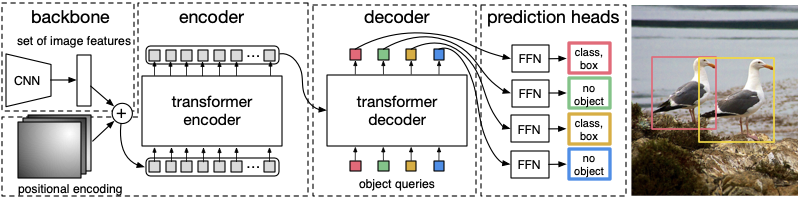

In [2]:
from flax import nnx
import jax.numpy as jnp

Let's first implement ResNet50 model using Flax NNX:

In [3]:
# Backbone ResNet50 implementation
class ResNet50(nnx.Module):
  def __init__(self, *, rngs: nnx.Rngs):
    self.stem = Stem(rngs=rngs)

    self.layer1 = BlockGroup(64, 64, 3, stride=1, rngs=rngs)
    self.layer2 = BlockGroup(256, 128, 4, stride=2, rngs=rngs)
    self.layer3 = BlockGroup(512, 256, 6, stride=2, rngs=rngs)
    self.layer4 = BlockGroup(1024, 512, 3, stride=2, rngs=rngs)
    self.pool = lambda x: nnx.avg_pool(x, (x.shape[1], x.shape[2]))
    self.fc = nnx.Linear(2048, 1000, rngs=rngs)

  def __call__(self, x):
    x = self.stem(x)
    x = self.layer1(x)
    x = self.layer2(x)
    x = self.layer3(x)
    x = self.layer4(x)
    x = self.pool(x)
    x = x.reshape((x.shape[0], x.shape[-1]))
    return self.fc(x)


class Stem(nnx.Module):
  def __init__(self, *, rngs: nnx.Rngs):
    self.conv = nnx.Conv(3, 64, kernel_size=(7, 7), strides=2, padding=3, use_bias=False, rngs=rngs)
    self.bn = nnx.BatchNorm(64, use_running_average=True, rngs=rngs)
    self.pool = lambda x: nnx.max_pool(x, window_shape=(3, 3), strides=(2, 2), padding=((1, 1), (1, 1)))

  def __call__(self, x):
    x = nnx.relu(self.bn(self.conv(x)))
    x = self.pool(x)
    return x


class BlockGroup(nnx.Module):
  def __init__(self, in_channels: int, out_channels: int, blocks, stride: int, *, rngs: nnx.Rngs):
    self.blocks = nnx.List()

    downsample = None
    if stride != 1 or in_channels != out_channels * 4:
      downsample = Downsample(in_channels, out_channels * 4, stride, rngs=rngs)

    self.blocks.append(Bottleneck(in_channels, out_channels, stride, downsample, rngs=rngs))
    for _ in range(1, blocks):
      self.blocks.append(Bottleneck(out_channels * 4, out_channels, stride=1, downsample=None, rngs=rngs))

  def __call__(self, x):
    for block in self.blocks:
      x = block(x)
    return x

class Bottleneck(nnx.Module):
  def __init__(self, in_channels: int, out_channels: int, stride: int = 1, downsample=None, *, rngs: nnx.Rngs):
    self.conv1 = nnx.Conv(
        in_channels, out_channels, kernel_size=(1, 1), strides=1, padding=0, use_bias=False, rngs=rngs
    )
    self.bn1 = nnx.BatchNorm(out_channels, use_running_average=True, rngs=rngs)

    self.conv2 = nnx.Conv(
        out_channels, out_channels, kernel_size=(3, 3), strides=stride, padding=1, use_bias=False, rngs=rngs
    )
    self.bn2 = nnx.BatchNorm(out_channels, use_running_average=True, rngs=rngs)

    self.conv3 = nnx.Conv(
        out_channels, out_channels * 4, kernel_size=(1, 1), strides=1, padding=0, use_bias=False, rngs=rngs
    )
    self.bn3 = nnx.BatchNorm(out_channels * 4, use_running_average=True, rngs=rngs)

    self.downsample = downsample

  def __call__(self, x):
    identity = x
    x = nnx.relu(self.bn1(self.conv1(x)))
    x = nnx.relu(self.bn2(self.conv2(x)))
    x = self.bn3(self.conv3(x))
    if self.downsample is not None:
      identity = self.downsample(identity)
    return nnx.relu(x + identity)


class Downsample(nnx.Module):
  def __init__(self, in_channels: int, out_channels: int, stride: int, *, rngs: nnx.Rngs):
    self.conv = nnx.Conv(
      in_channels, out_channels, kernel_size=(1, 1), strides=stride, padding=0, use_bias=False, rngs=rngs
    )
    self.bn = nnx.BatchNorm(out_channels, use_running_average=True, rngs=rngs)

  def __call__(self, x):
    return self.bn(self.conv(x))

Next, let's implement the standard Transformer model, i.e. encoder followed by decoder:

In [4]:
from typing import Callable

import jax
import jax.numpy as jnp
from flax import nnx


class TransformerEncoderLayer(nnx.Module):
    def __init__(
        self,
        hidden_size: int,
        num_heads: int,
        dim_feedforward: int = 2048,
        dropout: float = 0.1,
        activation: Callable = nnx.relu,
        use_bias: bool = True,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.mha = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=hidden_size,
            dropout_rate=dropout,
            deterministic=False,
            decode=False,
            use_bias=use_bias,
            rngs=rngs,
        )
        self.linear1 = nnx.Linear(hidden_size, dim_feedforward, use_bias=use_bias, rngs=rngs)
        self.linear2 = nnx.Linear(dim_feedforward, hidden_size, use_bias=use_bias, rngs=rngs)

        self.norm1 = nnx.LayerNorm(hidden_size, rngs=rngs)
        self.norm2 = nnx.LayerNorm(hidden_size, rngs=rngs)
        self.dropout = nnx.Dropout(dropout, rngs=rngs)
        self.activation = activation

    def __call__(
        self,
        x: jax.Array,
        mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = self.norm1(x + self.self_attn(x, mask, rngs=rngs))
        x = self.norm2(x + self.mlp(x, rngs=rngs))
        return x

    def self_attn(
        self,
        x: jax.Array,
        mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = self.mha(x, mask=mask, rngs=rngs)
        return self.dropout(x, rngs=rngs)

    def mlp(
        self,
        x: jax.Array,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(self.dropout(x, rngs=rngs))
        return self.dropout(x, rngs=rngs)


class TransformerDecoderLayer(nnx.Module):
    def __init__(
        self,
        hidden_size: int,
        num_heads: int,
        dim_feedforward: int = 2048,
        dropout: float = 0.1,
        activation: Callable = nnx.relu,
        use_bias: bool = True,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.mha1 = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=hidden_size,
            dropout_rate=dropout,
            deterministic=False,
            decode=False,
            use_bias=use_bias,
            rngs=rngs,
        )
        self.mha2 = nnx.MultiHeadAttention(
            num_heads=num_heads,
            in_features=hidden_size,
            dropout_rate=dropout,
            deterministic=False,
            decode=False,
            use_bias=use_bias,
            rngs=rngs,
        )
        self.linear1 = nnx.Linear(hidden_size, dim_feedforward, use_bias=use_bias, rngs=rngs)
        self.dropout = nnx.Dropout(dropout, rngs=rngs)
        self.linear2 = nnx.Linear(dim_feedforward, hidden_size, use_bias=use_bias, rngs=rngs)

        self.norm1 = nnx.LayerNorm(hidden_size, rngs=rngs)
        self.norm2 = nnx.LayerNorm(hidden_size, rngs=rngs)
        self.norm3 = nnx.LayerNorm(hidden_size, rngs=rngs)
        self.activation = activation

    def __call__(
        self,
        tgt: jax.Array,
        memory: jax.Array,
        tgt_mask: jax.Array | None = None,
        memory_mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = tgt
        x = self.norm1(x + self.self_attn(x, tgt_mask, rngs=rngs))
        x = self.norm2(x + self.cross_attn(x, memory, memory_mask, rngs=rngs))
        x = self.norm3(x + self.mlp(x, rngs=rngs))
        return x

    def self_attn(
        self,
        x: jax.Array,
        mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = self.mha1(x, mask=mask, rngs=rngs)
        return self.dropout(x, rngs=rngs)

    def cross_attn(
        self,
        x: jax.Array,
        mem: jax.Array,
        mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = self.mha2(x, mem, mask=mask, rngs=rngs)
        return self.dropout(x, rngs=rngs)

    def mlp(
        self,
        x: jax.Array,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = self.linear1(x)
        x = self.activation(x)
        x = self.linear2(self.dropout(x, rngs=rngs))
        return self.dropout(x, rngs=rngs)


class TransformerEncoder(nnx.Module):
    def __init__(
        self,
        num_layers: int,
        hidden_size: int,
        num_heads: int,
        dim_feedforward: int = 2048,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.layers = nnx.List([
            TransformerEncoderLayer(
                hidden_size,
                num_heads,
                dim_feedforward,
                dropout=0.1,
                activation=nnx.relu,
                use_bias=True,
                rngs=rngs,
            )
            for _ in range(num_layers)
        ])
        self.norm = nnx.LayerNorm(hidden_size, rngs=rngs)

    def __call__(
        self,
        src: jax.Array,
        mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = src
        for layer in self.layers:
            x = layer(x, mask, rngs=rngs)
        x = self.norm(x)
        return x


class TransformerDecoder(nnx.Module):
    def __init__(
        self,
        num_layers: int,
        hidden_size: int,
        num_heads: int,
        dim_feedforward: int = 2048,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.layers = nnx.List([
            TransformerDecoderLayer(
                hidden_size,
                num_heads,
                dim_feedforward,
                dropout=0.1,
                activation=nnx.relu,
                use_bias=True,
                rngs=rngs,
            )
            for _ in range(num_layers)
        ])
        self.norm = nnx.LayerNorm(hidden_size, rngs=rngs)

    def __call__(
        self,
        tgt: jax.Array,
        memory: jax.Array | None = None,
        tgt_mask: jax.Array | None = None,
        memory_mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        x = tgt
        for layer in self.layers:
            x = layer(x, memory, tgt_mask, memory_mask, rngs=rngs)
        x = self.norm(x)
        return x


class Transformer(nnx.Module):
    def __init__(
        self,
        hidden_size: int = 512,
        num_heads: int = 8,
        num_encoder_layers: int = 6,
        num_decoder_layers: int = 6,
        dim_feedforward: int = 2048,
        *,
        rngs: nnx.Rngs = nnx.Rngs(0),
    ):
        self.encoder = TransformerEncoder(
            num_encoder_layers,
            hidden_size,
            num_heads,
            dim_feedforward,
            rngs=rngs,
        )
        self.decoder = TransformerDecoder(
            num_decoder_layers,
            hidden_size,
            num_heads,
            dim_feedforward,
            rngs=rngs,
        )
        self.hidden_size = hidden_size
        self.num_heads = num_heads

    def __call__(
        self,
        src: jax.Array,
        tgt: jax.Array,
        src_mask: jax.Array | None = None,
        tgt_mask: jax.Array | None = None,
        memory_mask: jax.Array | None = None,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        if src.ndim != 3 or tgt.ndim != 3:
            raise ValueError("Expected batched inputs with shape (batch, seq, features)")
        if src.shape[-1] != self.hidden_size or tgt.shape[-1] != self.hidden_size:
            raise ValueError("The feature number of src and tgt must be equal to hidden_size")

        memory = self.encoder(src, src_mask, rngs=rngs)
        output = self.decoder(tgt, memory, tgt_mask, memory_mask, rngs=rngs)
        return output

Finally, let's implement the simplified DETR:

In [5]:
class MinimalDETR(nnx.Module):
    def __init__(
        self,
        num_classes: int,
        hidden_dim: int = 256,
        num_heads: int = 8,
        num_encoder_layers: int = 6,
        num_decoder_layers: int = 6,
        *,
        rngs: nnx.Rngs,
    ):
        # create ResNet-50 backbone
        self.backbone = ResNet50(rngs=rngs)
        del self.backbone.fc

        # create conversion layer
        self.conv = nnx.Conv(
            2048, hidden_dim, kernel_size=(1, 1), rngs=rngs
        )

        # create a default transformer
        self.transformer = Transformer(
            hidden_dim,
            num_heads,
            num_encoder_layers,
            num_decoder_layers,
            rngs=rngs,
        )

        # prediction heads, one extra class for predicting non-empty slots
        # note that in baseline DETR linear_bbox layer is 3-layer MLP
        self.linear_class = nnx.Linear(hidden_dim, num_classes + 1, rngs=rngs)
        self.linear_bbox = nnx.Linear(hidden_dim, 4, rngs=rngs)

        # output positional encodings (object queries)
        self.query_pos = nnx.Param(jax.random.normal(rngs.params(), (100, hidden_dim)))

        # spatial positional encodings
        # note that in baseline DETR we use sine positional encodings
        self.row_embed = nnx.Param(jax.random.uniform(rngs.params(), (50, hidden_dim // 2)))
        self.col_embed = nnx.Param(jax.random.uniform(rngs.params(), (50, hidden_dim // 2)))

    def __call__(
        self,
        inputs: jax.Array,
        *,
        rngs: nnx.Rngs | None = None,
    ) -> jax.Array:
        # propagate inputs through ResNet-50 up to avg-pool layer
        x = self.backbone.stem(inputs)
        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        # convert from 2048 to 256 feature planes for the transformer
        h = self.conv(x)
        # h: (B, H, W, E)

        # construct positional encodings
        bs, height, width = h.shape[:3]
        pos = jnp.concat([
           jnp.tile(self.col_embed[:width].reshape(1, width, -1), (height, 1, 1)),
           jnp.tile(self.row_embed[:height].reshape(height, 1, -1), (1, width, 1)),
        ], axis=-1).reshape((1, height * width, -1))
        # pos: (1, H * W, E)

        h = h.reshape(bs, -1, h.shape[-1])
        # h: (B, H * W, E)

        tgt = jnp.tile(jnp.expand_dims(self.query_pos, axis=0), (bs, 1, 1))
        # tgt: (B, 100, E)
        h = self.transformer(pos + 0.1 * h, tgt, rngs=rngs)

        # finally project transformer outputs to class labels and bounding boxes
        return {
            "pred_logits": self.linear_class(h),
            "pred_boxes": nnx.sigmoid(self.linear_bbox(h)),
        }

## Load pretrained weights from PyTorch

In order to avoid multiple memory allocations on the device e.g. NNX model random weights allocation, we can use ``nnx.eval_shape``. This function helps to create a state of the model with abstract arrays such that there is no memory allocation on the device and we replace all the abstract array with real arrays.

In [6]:
num_classes = 91

model = nnx.eval_shape(lambda : MinimalDETR(num_classes, rngs=nnx.Rngs(0)))
graph_def, abs_state = nnx.split(model)
jax_state = nnx.to_pure_dict(abs_state)
print(len(jax_state), list(jax_state.keys())[:3], type(next(iter(jax_state.values()))))
# 8 ['backbone', 'col_embed', 'conv'] <class 'dict'>

8 ['backbone', 'col_embed', 'conv'] <class 'dict'>


In [7]:
import torch


state_dict = torch.hub.load_state_dict_from_url(
    url='https://dl.fbaipublicfiles.com/detr/detr_demo-da2a99e9.pth',
    map_location='cpu', 
    check_hash=True,
)

In the next cell we define the parameters keys mapping and rules how to transform PyTorch tensors into corresponding JAX Arrays.

In [9]:
def get_key_and_transform_mapping():
  from enum import Enum

  class Transform(Enum):
    BIAS = None
    DEFAULT = None
    LINEAR = (1, 0)
    CONV2D = (2, 3, 1, 0)
    ATTN_IN_PROJ_WEIGHT = 'attn_in_proj_weight'
    ATTN_IN_PROJ_BIAS = 'attn_in_proj_bias'

  return {
    # Backbone
    r"^backbone\.conv1\.weight$": ("backbone.stem.conv.kernel", Transform.CONV2D),
    r"^backbone\.bn1\.weight$": ("backbone.stem.bn.scale", Transform.DEFAULT),
    r"^backbone\.bn1\.bias$": ("backbone.stem.bn.bias", Transform.BIAS),
    r"^backbone\.bn1\.running_mean$": ("backbone.stem.bn.mean", Transform.DEFAULT),
    r"^backbone\.bn1\.running_var$": ("backbone.stem.bn.var", Transform.DEFAULT),
    r"^backbone\.layer([1-4])\.([0-9]+)\.conv([1-3])\.weight$": (
      r"backbone.layer\1.blocks.\2.conv\3.kernel",
      Transform.CONV2D,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.bn([1-3])\.weight$": (
      r"backbone.layer\1.blocks.\2.bn\3.scale",
      Transform.DEFAULT,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.bn([1-3])\.bias$": (
      r"backbone.layer\1.blocks.\2.bn\3.bias",
      Transform.BIAS,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.bn([1-3])\.running_mean$": (
      r"backbone.layer\1.blocks.\2.bn\3.mean",
      Transform.DEFAULT,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.bn([1-3])\.running_var$": (
      r"backbone.layer\1.blocks.\2.bn\3.var",
      Transform.DEFAULT,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.downsample\.0\.weight$": (
      r"backbone.layer\1.blocks.\2.downsample.conv.kernel",
      Transform.CONV2D,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.downsample\.1\.weight$": (
      r"backbone.layer\1.blocks.\2.downsample.bn.scale",
      Transform.DEFAULT,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.downsample\.1\.bias$": (
      r"backbone.layer\1.blocks.\2.downsample.bn.bias",
      Transform.BIAS,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.downsample\.1\.running_mean$": (
      r"backbone.layer\1.blocks.\2.downsample.bn.mean",
      Transform.DEFAULT,
    ),
    r"^backbone\.layer([1-4])\.([0-9]+)\.downsample\.1\.running_var$": (
      r"backbone.layer\1.blocks.\2.downsample.bn.var",
      Transform.DEFAULT,
    ),

    # Positional embeddings
    r"^row_embed$": ("row_embed", Transform.DEFAULT),
    r"^col_embed$": ("col_embed", Transform.DEFAULT),
    r"^query_pos$": ("query_pos", Transform.DEFAULT),

    # Conv projection and linear heads
    r"^conv\.weight$": ("conv.kernel", Transform.CONV2D),
    r"^conv\.bias$": ("conv.bias", Transform.BIAS),
    r"^linear_bbox\.weight$": ("linear_bbox.kernel", Transform.LINEAR),
    r"^linear_bbox\.bias$": ("linear_bbox.bias", Transform.BIAS),
    r"^linear_class\.weight$": ("linear_class.kernel", Transform.LINEAR),
    r"^linear_class\.bias$": ("linear_class.bias", Transform.BIAS),

    # Transformer encoder layers
    r"^transformer\.encoder\.layers\.([0-9]+)\.self_attn\.in_proj_weight$": (
      r"transformer.encoder.layers.\1.mha",
      Transform.ATTN_IN_PROJ_WEIGHT,
    ),
    r"^transformer\.encoder\.layers\.([0-9]+)\.self_attn\.in_proj_bias$": (
      r"transformer.encoder.layers.\1.mha",
      Transform.ATTN_IN_PROJ_BIAS,
    ),
    r"^transformer\.encoder\.layers\.([0-9]+)\.self_attn\.out_proj.weight$": (
      r"transformer.encoder.layers.\1.mha.out.kernel",
      Transform.LINEAR,
    ),
    r"^transformer\.encoder\.layers\.([0-9]+)\.self_attn\.out_proj.bias$": (
      r"transformer.encoder.layers.\1.mha.out.bias",
      Transform.BIAS,
    ),
    r"^transformer\.encoder\.layers\.([0-9]+)\.linear([1-2])\.weight$": (
      r"transformer.encoder.layers.\1.linear\2.kernel",
      Transform.LINEAR,
    ),
    r"^transformer\.encoder\.layers\.([0-9]+)\.linear([1-2])\.bias$": (
      r"transformer.encoder.layers.\1.linear\2.bias",
      Transform.BIAS,
    ),
    r"^transformer\.encoder\.layers\.([0-9]+)\.norm([1-2])\.weight$": (
      r"transformer.encoder.layers.\1.norm\2.scale",
      Transform.DEFAULT,
    ),
    r"^transformer\.encoder\.layers\.([0-9]+)\.norm([1-2])\.bias$": (
      r"transformer.encoder.layers.\1.norm\2.bias",
      Transform.BIAS,
    ),
    r"^transformer\.encoder\.norm\.weight$": (
      r"transformer.encoder.norm.scale",
      Transform.DEFAULT,
    ),
    r"^transformer\.encoder\.norm\.bias$": (
      r"transformer.encoder.norm.bias",
      Transform.BIAS,
    ),

    # Transformer decoder layers
    r"^transformer\.decoder\.layers\.([0-9]+)\.self_attn\.in_proj_weight$": (
      r"transformer.decoder.layers.\1.mha1",
      Transform.ATTN_IN_PROJ_WEIGHT,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.self_attn\.in_proj_bias$": (
      r"transformer.decoder.layers.\1.mha1",
      Transform.ATTN_IN_PROJ_BIAS,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.self_attn\.out_proj.weight$": (
      r"transformer.decoder.layers.\1.mha1.out.kernel",
      Transform.LINEAR,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.self_attn\.out_proj.bias$": (
      r"transformer.decoder.layers.\1.mha1.out.bias",
      Transform.BIAS,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.multihead_attn\.in_proj_weight$": (
      r"transformer.decoder.layers.\1.mha2",
      Transform.ATTN_IN_PROJ_WEIGHT,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.multihead_attn\.in_proj_bias$": (
      r"transformer.decoder.layers.\1.mha2",
      Transform.ATTN_IN_PROJ_BIAS,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.multihead_attn\.out_proj.weight$": (
      r"transformer.decoder.layers.\1.mha2.out.kernel",
      Transform.LINEAR,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.multihead_attn\.out_proj.bias$": (
      r"transformer.decoder.layers.\1.mha2.out.bias",
      Transform.BIAS,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.linear([1-2])\.weight$": (
      r"transformer.decoder.layers.\1.linear\2.kernel",
      Transform.LINEAR,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.linear([1-2])\.bias$": (
      r"transformer.decoder.layers.\1.linear\2.bias",
      Transform.BIAS,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.norm([1-3])\.weight$": (
      r"transformer.decoder.layers.\1.norm\2.scale",
      Transform.DEFAULT,
    ),
    r"^transformer\.decoder\.layers\.([0-9]+)\.norm([1-3])\.bias$": (
      r"transformer.decoder.layers.\1.norm\2.bias",
      Transform.BIAS,
    ),
    r"^transformer\.decoder\.norm\.weight$": (
      r"transformer.decoder.norm.scale",
      Transform.DEFAULT,
    ),
    r"^transformer\.decoder\.norm\.bias$": (
      r"transformer.decoder.norm.bias",
      Transform.BIAS,
    ),
  }

def map_to_nnx_key(mapping, source_key):
  import re

  subs = [
    (re.sub(pat, repl, source_key), transform)
    for pat, (repl, transform) in mapping.items()
    if re.match(pat, source_key)
  ]
  if not subs:
    if "num_batches_tracked" not in source_key:
      print(f"No mapping found for key: {source_key!r}")
    return None, None
  if len(subs) > 1:
    keys = [s for s, _ in subs]
    raise ValueError(f"Multiple mappings found for {source_key!r}: {keys}")
  return subs[0]

def stoi(s: str) -> int | str:
  try:
    return int(s)
  except ValueError:
    return s


def assign_weights_from_eval_shape(
  keys: list[str], tensor: torch.Tensor, state_dict: dict, st_key: str, transform
):
  obj = jax_state
  for key in keys[:-1]:
    obj = obj[key]
  key = keys[-1]

  def tensor_to_array(tensor, ref_obj):
    data = jnp.asarray(tensor, dtype=ref_obj.dtype)      
    # if hasattr(ref_obj, "sharding") and ref_obj.sharding is not None:
    #   data = jax.device_put(data, ref_obj.sharding.spec)
    return data

  if transform == "attn_in_proj_weight":
    qkv = [t for t in tensor.chunk(3)]
    for name, data in zip(["query", "key", "value"], qkv):
      shape = obj[key][name]["kernel"].shape
      obj[key][name]["kernel"] = tensor_to_array(
          data.permute(1, 0).reshape(shape), obj[key][name]["kernel"])
    return
  elif transform == "attn_in_proj_bias":
    qkv = [t for t in tensor.chunk(3)]
    for name, data in zip(["query", "key", "value"], qkv):
      shape = obj[key][name]["bias"].shape
      obj[key][name]["bias"] = tensor_to_array(
          data.reshape(shape), obj[key][name]["bias"])
    return
  elif isinstance(transform, tuple):
    if len(transform) != tensor.ndim:
      raise ValueError(f"Shape mismatch for {st_key}: {tensor.shape} vs {obj[key].shape} vs {transform=}")
    tensor = tensor.permute(transform)
    if tensor.shape != obj[key].shape:
      tensor = tensor.reshape(obj[key].shape)
    
  if tensor.shape != obj[key].shape:
    raise ValueError(f"Shape mismatch for {st_key}: {tensor.shape} vs {obj[key].shape}")

  obj[key] = tensor_to_array(tensor, obj[key])

mapping = get_key_and_transform_mapping()
for st_key, tensor in state_dict.items():
  jax_key, transform = map_to_nnx_key(mapping, st_key)
  if jax_key is None:
    continue
  keys = [stoi(k) for k in jax_key.split(".")]
  assign_weights_from_eval_shape(keys, tensor, jax_state, st_key, transform.value)

model = nnx.merge(graph_def, jax_state)

# finally let's reseed the stochastic layers
nnx.reseed(model, default=123)

## Inference with DETR

Let's set model's attributes to the detereministic state for the evaluation:

In [11]:
eval_model = nnx.view(model, deterministic=True, use_running_average=True)

Let's define few helper functions to make the predictions and transform obtained bounding boxes into XYXY format:

In [17]:
def box_cxcywh_to_xyxy(boxes: jax.Array) -> jax.Array:
    wh = boxes[:, 2:]
    return jnp.concat([boxes[:, :2] - 0.5 * wh, boxes[:, :2] + 0.5 * wh], axis=-1)    


def rescale_bboxes(
    out_bbox: jax.Array, size: tuple[int, int]
) -> jax.Array:
    img_w, img_h = size
    b = box_cxcywh_to_xyxy(out_bbox)
    b = b * jnp.asarray([img_w, img_h, img_w, img_h], dtype=jnp.float32)
    return b


@jax.jit
def detect(
    model: nnx.Module, 
    img: jax.Array, 
    confidence: float = 0.7
) -> jax.Array:
    # Resize to 800 max size:
    h, w = img.shape[0], img.shape[1]
    new_h, new_w = (800, w / h * 800) if h > w else (h / w * 800, 800)
    shape = (int(new_h), int(new_w), img.shape[2])
    img = jax.image.resize(img, shape, method="bilinear")
    
    # Normalize:
    img = img / 255.0
    mean = jnp.asarray([0.485, 0.456, 0.406])
    std = jnp.asarray([0.229, 0.224, 0.225])
    img = (img - mean) / std

    # Add batch dim:
    img = img[None, ...]
    
    outputs = model(img)

    # keep only predictions with confidence
    probas = jax.nn.softmax(outputs['pred_logits'], -1)[0, :, :-1]
    keep = probas.max(-1) > confidence
    
    # convert boxes from [0; 1] to image scales
    bboxes_scaled = rescale_bboxes(outputs['pred_boxes'][0], (w, h))
    
    return probas, bboxes_scaled, keep

Finally, we can fetch an image from COCO validation dataset and run the detection and plot the results

In [24]:
import requests
from PIL import Image

url = 'http://images.cocodataset.org/val2017/000000039769.jpg'
im1 = Image.open(requests.get(url, stream=True).raw)

url = "https://github.com/pytorch/vision/blob/main/gallery/assets/dog1.jpg?raw=true"
im2 = Image.open(requests.get(url, stream=True).raw)

In [25]:
# COCO classes
coco_classes = [
    'N/A', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A',
    'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse',
    'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack',
    'umbrella', 'N/A', 'N/A', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis',
    'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove',
    'skateboard', 'surfboard', 'tennis racket', 'bottle', 'N/A', 'wine glass',
    'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich',
    'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake',
    'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table', 'N/A',
    'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A',
    'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier',
    'toothbrush'
]

# colors for visualization
colors = [[0.000, 0.447, 0.741], [0.850, 0.325, 0.098], [0.929, 0.694, 0.125],
          [0.494, 0.184, 0.556], [0.466, 0.674, 0.188], [0.301, 0.745, 0.933]]

In [26]:
img = jnp.asarray(im1)
scores, boxes, keep = detect(eval_model, img, confidence=0.7)
scores1 = scores[keep]
boxes1 = boxes[keep]

img = jnp.asarray(im2)
scores, boxes, keep = detect(eval_model, img, confidence=0.7)
scores2 = scores[keep]
boxes2 = boxes[keep]

E0602 15:42:00.880309   45559 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0602 15:42:01.180018   45578 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0602 15:42:01.664495   45549 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0602 15:42:02.302050   45589 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0602 15:42:02.846607   45580 cuda_timer.cc:87] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0602 15:42:03.100975   45567 cuda_timer.cc:8

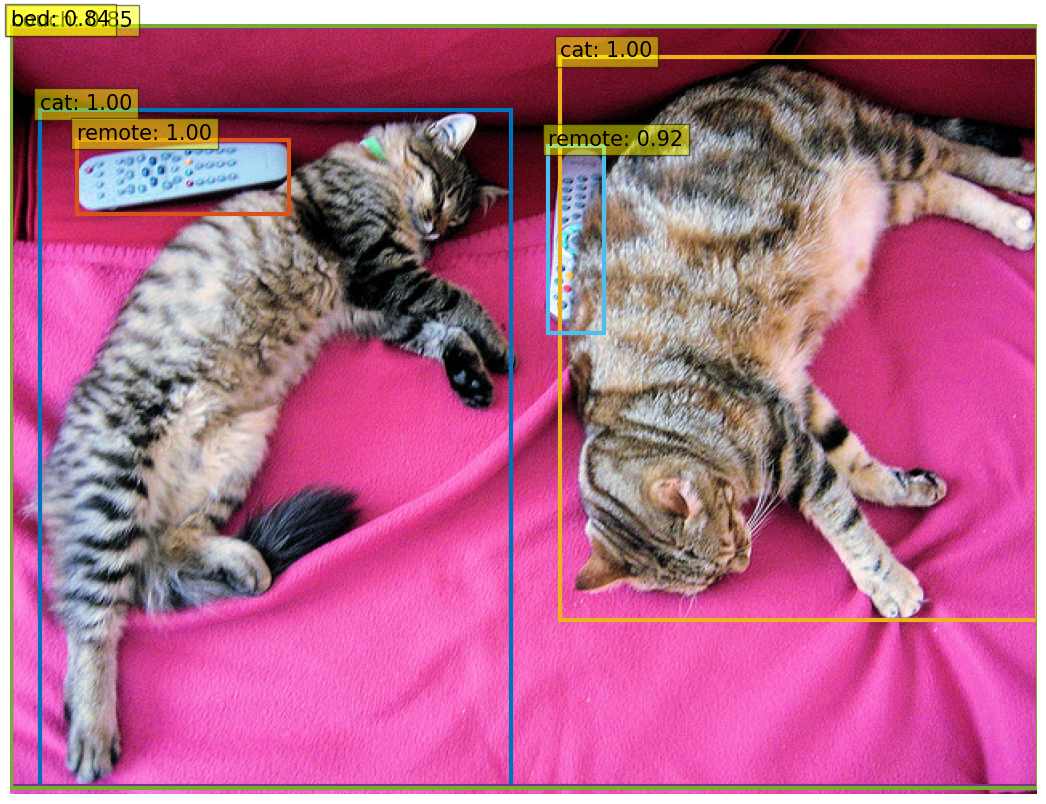

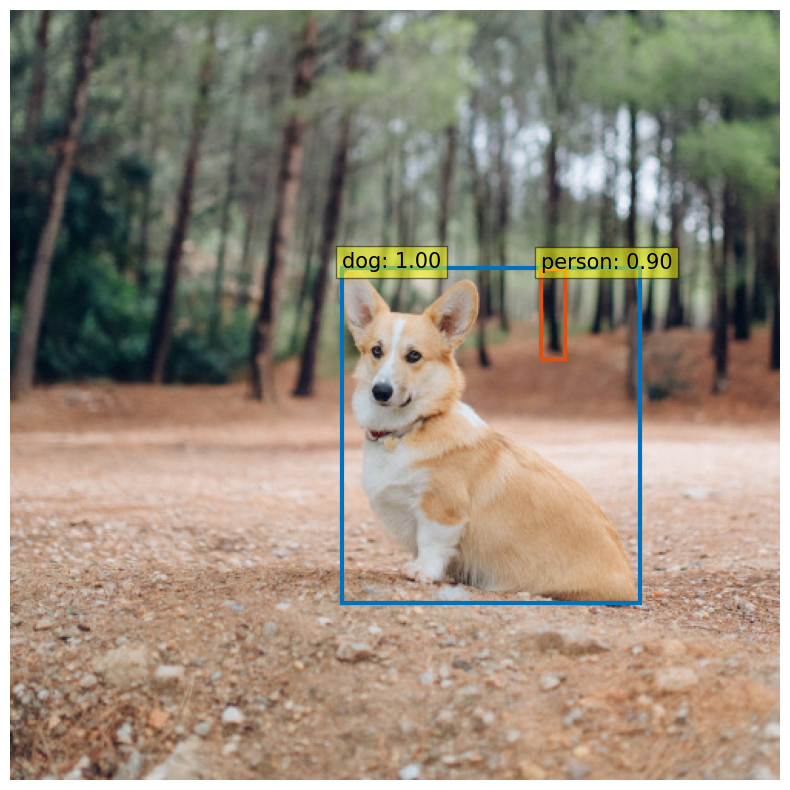

In [27]:
import matplotlib.pyplot as plt

def plot_results(pil_img, prob, boxes):
    plt.figure(figsize=(16,10))
    plt.imshow(pil_img)
    ax = plt.gca()
    for p, (xmin, ymin, xmax, ymax), c in zip(prob, boxes.tolist(), colors * 100):
        ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                   fill=False, color=c, linewidth=3))
        cl = p.argmax()
        text = f'{coco_classes[cl]}: {p[cl]:0.2f}'
        ax.text(xmin, ymin, text, fontsize=15,
                bbox=dict(facecolor='yellow', alpha=0.5))
    plt.axis('off')
    plt.show()
    
plot_results(im1, scores1, boxes1)
plot_results(im2, scores2, boxes2)

## Further reading

In this example we implemented the DETR model, loaded pretrained weights and run inference with the model on few images.

For further reading, check out other Examples.